# Practical concerns on large-scale training

So far we have witnessed quite some modern optimizers, are we ready to go ahead and apply them directly on training extreme large models? The answer is no. For example, we still don't know how to choose learning rate, how to make it efficient on multiple (sometimes hundred or thousands of) GPUs, etc. In this section we briefly discuss several techniques popular in practice. We will not be able to provide all techincal details but will introduce related concepts and references for further readings.

## lr scheduler

Let's begin with the first topic: how to choose the most important hyperparameter, namely the learning rate. Let's take a look at the AdamW algorithm again.

````{prf:algorithm} AdamW
:label: alg:adamw_again

- **Input**: initial point $\vw^0$, learning rate sequence $\{ \eta_t \}_{t \geq 0}$, max. no. of iterations $T$, momentum parameter $(\beta_1,\beta_2)$, weight decay parameter $\lambda$.

- For $t=0,1,2,..., T-1$,
```{math}
\begin{split}
\xi_{i_{j,t}} &\sim {\cal D} \text{ (draw i.i.d. samples)} \\
\vg^t &\leftarrow \frac{1}{B}\sum_{j=1}^{B}\nabla \ell(\vw^t, \xi_{i_{j,t}}) \\
\vm^t &\leftarrow \beta_1\vm^{t-1} + (1-\beta_1)\vg^t \\
\vv^t &\leftarrow \beta_2\vv^{t-1} + (1-\beta_2)\vg^t\odot \vg^t \\
\hat{\vm}^t &\gets \frac{\vm^t}{1-\beta_1^t},\ \hat{\vv}^t \gets \frac{\vm^t}{1-\beta_2^t} \\
\vw^{t+1} &\leftarrow \vw^{t} - \eta_t \frac{\hat{\vm}^t}{\sqrt{\hat{\vv}^t}+\epsilon} - \eta_t\lambda \vw^{t}
\end{split}
```
- **Output**: last iterate $\vw^T$, or the solution sequence $\{ \vw^t \}_{t=1}^T$.
````
You can see that we did not specify the choice of $\eta_t$ for a given $t$. According to {prf:ref}`thm:sgd-smooth`, we need to take $\eta_t\leq 1/L$, where $L$ is the Lipschitz constant of the gradient of the loss function. In the paragraph right after, we gave two concrete choices of $\eta_t=1/(\sqrt{t} L)$ and $\eta_t=1/(\sqrt{T} L)$, which suggests that we take a **diminishing** learning rate: at the beginning the learning rate is large, then it gradually decrease to zero. Such a scheduler for the learning rate is usually called the learning rate (lr) schedule. Below, we will discuss several lr-schedules that people use in practice.

**Constant schedule**. The first is the constant scuedule, which simply takes the lr $\eta_t=\eta$ being a constant. Ideally this constant should just be $1/(\sqrt{T} L)$. However in practice, it is highly un-preferred due to two reasons: First, constant learning rate will result in a less stable training, especially in the late stage of the training (imagine that we are already near optimal, where we have to be very cautious about our updates, but constant lr makes update as fast as the beginning of the training); Second, it is almost impossible to compute $L$ for large models, leaving a huge computational burden for hyperparameter search.

**Linear, Inverse-sqrt and Cosine decay**. These three lr schedules are the most commonly used in practice. For linear schedule {cite}`devlin2019bert`, the update is
```{math}
\eta_t = (1 - \frac{t}{T})\eta_0,\ \forall t=1,2,...,T
```
where $\eta_0$ is the initial (largest) lr. For inverse sqrt schedule {cite}`vaswani2017attention`, which we have already discussed in our theory, the update is:
```{math}
\eta_t = \eta_0/\sqrt{t},\ \forall t=1,2,...,T
```
For cosine schedule {cite}`loshchilov2017sgdr`, the update is
```{math}
\eta_t = \frac{1}{2}\left[ 1+\cos(\pi \frac{t}{T}) \right]\eta_0,\ \forall t=1,2,...,T
```
In practice, linear and cosine schedules are more popular, since they assign larger lr for the beginning stage of training and smaller lr for the late stage of training, thus make the training more stable in the late stage.

**Warmup**. Warmup is a quite useful notion for the beginning stage of the training, which is adaopted in literally all the mainstream model training. As we discussed, the lr should be small in the late stage of training to ensure stability. However for the very very early stage, say the first few hundred steps, the model is essentially just randomly initialized and the update is taking the model drastically toward fitting the initial data batches if we have very large learning rates. That's to say, for the very beginning of the training, large learning rate could also harm the training. Therefore a remedy people widely adopt is to increase the lr quickly from zero to the maximum for the first few hundred iterations. Warmup can be easily combined with any lr schedule to form a "increase-then-decrease" schedule, for example, GPT-3 {cite}`brown2020language` uses warmup-then-cosine-decay schedule in their model training.

**WSD schedule and river-valley landscape**. With warmup, a new type of lr schedule emerge, which is known as the "warmup-stable-decay" or WSD schedule. The notion is that the lr should be a constant after the warmup stage to boost the performance, then start to decay after say 50% of the training steps are consumed. Such a schedule is backed by the so-called "river-valley landscape" {cite}`wen2025understanding`, indicating that the decay phase should be happening only at the later stage of the training to track the "river valley" shaped loss.

Now, at the end of this subsection, we provide a simple python code showing the shape of different lr schedules.

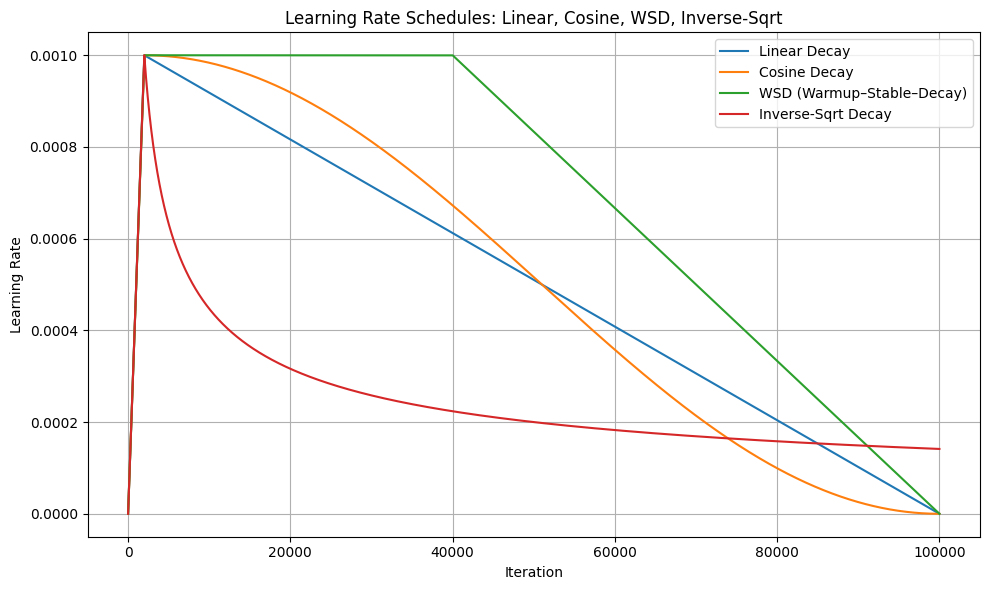

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
eta0 = 1e-3         # base/max learning rate
T = 100_000         # total iterations
warmup_frac = 0.02  # 2% warmup
stable_frac = 0.40  # WSD: 40% stable period after warmup

t_w = int(T * warmup_frac)
t_s = int(T * stable_frac)  # end of stable region (for WSD)

# --------------------------
# LR SCHEDULE DEFINITIONS
# --------------------------

def lr_linear(t):
    """Linear warmup, then linear decay to 0."""
    if t < t_w:  # warmup
        if t_w == 0:
            return eta0
        return eta0 * t / t_w
    # linear decay from warmup to end
    return eta0 * (1 - (t - t_w) / (T - t_w))


def lr_cosine(t):
    """Linear warmup, then cosine decay to 0."""
    if t < t_w:  # warmup
        if t_w == 0:
            return eta0
        return eta0 * t / t_w
    x = (t - t_w) / (T - t_w)
    return eta0 * 0.5 * (1 + np.cos(np.pi * x))


def lr_wsd(t):
    """Warmup -> Stable -> linear Decay."""
    if t < t_w:  # warmup
        if t_w == 0:
            return eta0
        return eta0 * t / t_w
    elif t < t_s:  # stable phase
        return eta0
    # final decay (linear)
    return eta0 * (1 - (t - t_s) / (T - t_s))


def lr_inv_sqrt(t):
    """
    Inverse-sqrt schedule with warmup.

    Warmup:  LR(t) = eta0 * t / t_w
    Decay:   LR(t) = eta0 * sqrt(t_w / t)
    """
    if t == 0:
        return 0.0
    if t < t_w and t_w > 0:
        return eta0 * t / t_w
    # inverse-sqrt decay after warmup
    return eta0 * np.sqrt(t_w / t)


# --------------------------
# GENERATE VALUES
# --------------------------
ts = np.arange(T + 1)
linear_lrs = np.array([lr_linear(t) for t in ts])
cosine_lrs = np.array([lr_cosine(t) for t in ts])
wsd_lrs = np.array([lr_wsd(t) for t in ts])
inv_sqrt_lrs = np.array([lr_inv_sqrt(t) for t in ts])

# --------------------------
# PLOT
# --------------------------
plt.figure(figsize=(10, 6))
plt.plot(ts, linear_lrs, label="Linear Decay")
plt.plot(ts, cosine_lrs, label="Cosine Decay")
plt.plot(ts, wsd_lrs, label="WSD (Warmup–Stable–Decay)")
plt.plot(ts, inv_sqrt_lrs, label="Inverse-Sqrt Decay")

plt.xlabel("Iteration")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedules: Linear, Cosine, WSD, Inverse-Sqrt")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## $\mu$P and hyperparameter transfer

Suppose you train a 1B model, searched for the learning rates, and find the optimal one. One simply yet very profound question is that: does this learning rate really carry over to larger models? Say if you want to train a 7B model, are you still able to reuse the same hyperparameter, or if they no longer work?

Unfortunately, usually the optimal hyperparameters for one model would not be the optimal for the other. There are a lot of efforts of making these hyperparameter transferable {cite}`yang2022tensor,yang2023spectral`. Below we briefly describe the idea of $\mu$P (transferable learning rate) in {cite}`yang2023spectral`.

For different model sizes and structures, the training could not use the same learning rate, mainly due to the fact that the dimension of the attention matrices (and other weight matrices) are different. If you use $\eta=0.001$ for a $256$ by $256$ gradient matrix, you will need to scale it down for a $512$ by $512$ gradient matrix to make sure that the magnitude of the change at each iteration ($\|W^{t+1}-W^{t}\|$) remain roughly the same order. Based on this notion, **the optimal learning rate should be directly dependent on the dimension of the gradient matrices**, and this is exactly the key idea of $\mu$P. We refer to {cite}`yang2023spectral` if you are interested in the details.




## Infra discussions: distributed training, mixed precision training and more

When we get a training algorithm such as {prf:ref}`alg:adamw_again`, it is straightforward to write it into pytorch optimizer code. However there are still a lot of practical concerns. For example, say that you are having 8 devices, each of them has 8 A100 GPUs. How to distribute the model and the gradient into different devices and GPUs for high performance parallel training? Also, by default models are loaded in [FP32](https://en.wikipedia.org/wiki/Single-precision_floating-point_format) floating point precision, and how can we reduce the memory consumption by loading to in BF16, or even lower precisions (see this [NVIDIA post](https://docs.nvidia.com/deeplearning/performance/pdf/Training-Mixed-Precision-User-Guide.pdf) for more discussion on this)?

These are far beyond the scope of this work, however these are realistic infrastructure problems that AI engineers try to solve on a daily basis. 

For distributed training, pytorch supports [DDP](https://docs.pytorch.org/tutorials/intermediate/ddp_tutorial.html), [FSDP](https://docs.pytorch.org/tutorials/intermediate/FSDP_tutorial.html) for parallel computing, Microsoft has the [DeepSpeed](https://github.com/deepspeedai/DeepSpeed) distributed computing engine, and NVIDIA has the [Megatron](https://github.com/NVIDIA/Megatron-LM) distributed training pipeline. It is very common that with infra side innovations, all the algorithm performances improve significantly, even much more than proposing new but incremental training algorithms (such as making some minor changes on AdamW).